# EDA: Enriched Hate Speech Dataset

Formal exploratory data analysis of the enriched, bilingual (English +
Spanish) hate-speech dataset built in `specs/004-dataset-enrichment/spec.md`
and preprocessed in `specs/006-text-preprocessing/spec.md`.

**Goal:** understand class balance, language balance, category coverage,
comment-length distribution, duplicates, and vocabulary — to inform the
next tasks (vectorization and model training in
`specs/001-hate-speech-detection/tasks.md`).

All plots below are embedded as static outputs in this notebook file —
opening it on GitHub renders the results without needing to re-run
anything. To regenerate: `jupyter nbconvert --to notebook --execute
--inplace notebooks/eda_enriched_dataset.ipynb`.

In [1]:
import sys
sys.path.insert(0, "..")

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from wordcloud import WordCloud

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100

df = pd.read_csv("../data/processed/enriched_comments.csv")
df_clean = pd.read_csv("../data/processed/enriched_comments_preprocessed.csv")
print(f"enriched_comments.csv: {df.shape}")
print(f"enriched_comments_preprocessed.csv: {df_clean.shape}")

enriched_comments.csv: (133808, 5)
enriched_comments_preprocessed.csv: (133808, 6)


## 1. Overview

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 133808 entries, 0 to 133807
Data columns (total 5 columns):
 #   Column      Non-Null Count   Dtype
---  ------      --------------   -----
 0   comment     133808 non-null  str  
 1   language    133808 non-null  str  
 2   label       133808 non-null  int64
 3   categories  133808 non-null  str  
 4   source      133808 non-null  str  
dtypes: int64(1), str(4)
memory usage: 26.4 MB


In [3]:
df.head(5)

,comment,language,label,categories,source
0,If only people would just take a step back and...,en,0,other,youtoxic
1,Law enforcement is not trained to shoot to app...,en,0,other,youtoxic
2,\nDont you reckon them 'black lives matter' ba...,en,0,other,youtoxic
3,There are a very large number of people who do...,en,0,other,youtoxic
4,"The Arab dude is absolutely right, he should h...",en,0,other,youtoxic


In [4]:
print("Missing values per column:")
print(df.isna().sum())

Missing values per column:
comment       0
language      0
label         0
categories    0
source        0
dtype: int64


**Finding:** no missing values in any column. The dataset has the 5
normalized columns from `src/data/harmonize.py`
(`comment, language, label, categories, source`), one row per comment
across 9 combined sources.

## 2. Class balance (hate vs. not-hate)

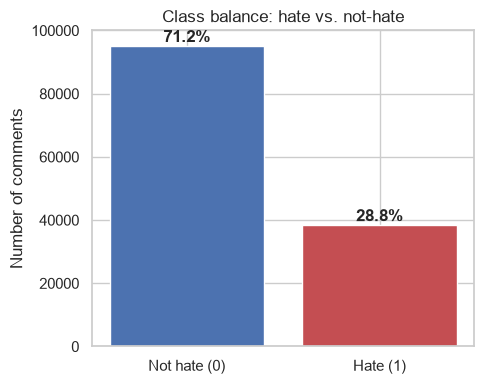

label
0    95246
1    38562
Name: count, dtype: int64
label
0    71.2
1    28.8
Name: count, dtype: float64


In [5]:
label_counts = df["label"].value_counts().sort_index()
label_pct = (label_counts / len(df) * 100).round(1)

fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(["Not hate (0)", "Hate (1)"], label_counts.values, color=["#4C72B0", "#C44E52"])
for bar, pct in zip(bars, label_pct.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f"{pct}%",
            ha="center", va="bottom", fontweight="bold")
ax.set_ylabel("Number of comments")
ax.set_title("Class balance: hate vs. not-hate")
plt.tight_layout()
plt.show()

print(label_counts)
print(label_pct)

**Finding:** ~28.8% of comments are labeled hateful (38,562 / 133,808).
This is a real, moderate class imbalance (roughly 1:2.5) — not as severe as
the original briefing dataset alone (13.8%), but still enough that later
evaluation should report precision/recall/F1 per class, not just overall
accuracy, and model training should consider class weighting.

## 3. Language distribution

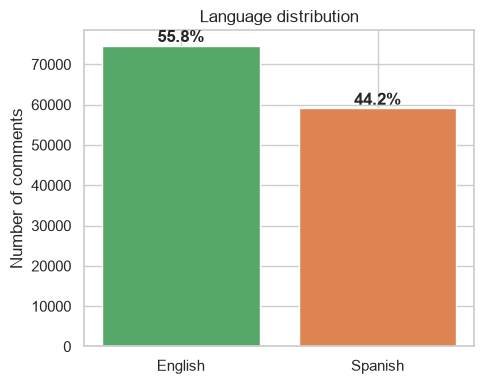

language
en    74682
es    59126
Name: count, dtype: int64
language
en    55.8
es    44.2
Name: count, dtype: float64


In [6]:
lang_counts = df["language"].value_counts()
lang_pct = (lang_counts / len(df) * 100).round(1)

fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(lang_counts.index.map({"en": "English", "es": "Spanish"}), lang_counts.values,
              color=["#55A868", "#DD8452"])
for bar, pct in zip(bars, lang_pct.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f"{pct}%",
            ha="center", va="bottom", fontweight="bold")
ax.set_ylabel("Number of comments")
ax.set_title("Language distribution")
plt.tight_layout()
plt.show()

print(lang_counts)
print(lang_pct)

**Finding:** the dataset is close to bilingual parity — 55.8% English
(74,682 rows), 44.2% Spanish (59,126 rows), after deliberately adding 5
Spanish-only sources (HatEval's Spanish half, HaterNet, OffendES,
HaSCoSVa, DETESTS) on top of the briefing's English-only starting point.
This makes the dataset suitable for a genuinely bilingual model, though a
per-language evaluation breakdown is recommended since vocabulary,
stopwords, and hate expression differ structurally between the two.

## 4. Source distribution

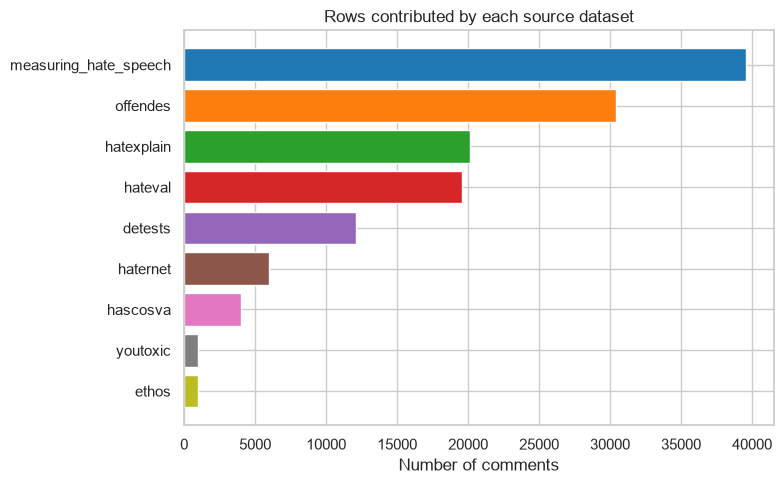

source
measuring_hate_speech    39565
offendes                 30416
hatexplain               20148
hateval                  19570
detests                  12111
haternet                  6000
hascosva                  4000
youtoxic                  1000
ethos                      998
Name: count, dtype: int64


In [7]:
source_counts = df["source"].value_counts()

fig, ax = plt.subplots(figsize=(8, 5))
colors = sns.color_palette("tab10", len(source_counts))
ax.barh(source_counts.index[::-1], source_counts.values[::-1], color=colors[::-1])
ax.set_xlabel("Number of comments")
ax.set_title("Rows contributed by each source dataset")
plt.tight_layout()
plt.show()

print(source_counts)

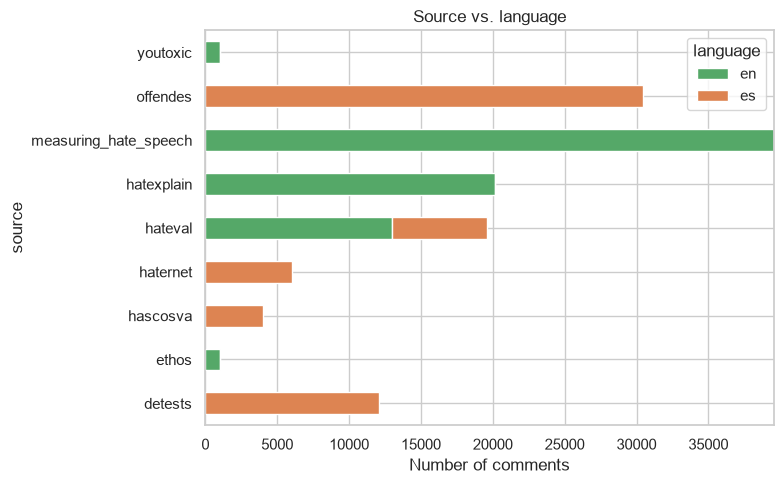

language                  en     es
source                             
detests                    0  12111
ethos                    998      0
hascosva                   0   4000
haternet                   0   6000
hateval                12971   6599
hatexplain             20148      0
measuring_hate_speech  39565      0
offendes                   0  30416
youtoxic                1000      0


In [8]:
source_lang = pd.crosstab(df["source"], df["language"])
source_lang.plot(kind="barh", stacked=True, figsize=(8, 5), color=["#55A868", "#DD8452"])
plt.xlabel("Number of comments")
plt.title("Source vs. language")
plt.tight_layout()
plt.show()

print(source_lang)

**Finding:** `measuring_hate_speech` (39,565) and `offendes` (30,416) are
the two largest contributors, together ~52% of the dataset. Every source
is strictly monolingual except `hateval`, which has both English and
Spanish splits. This means the dataset's topical/stylistic diversity
within each language is bounded by how many distinct sources exist for
that language — Spanish has 6 sources, English has 4 (counting `hateval`
in both).

## 5. Category distribution (among hateful comments)

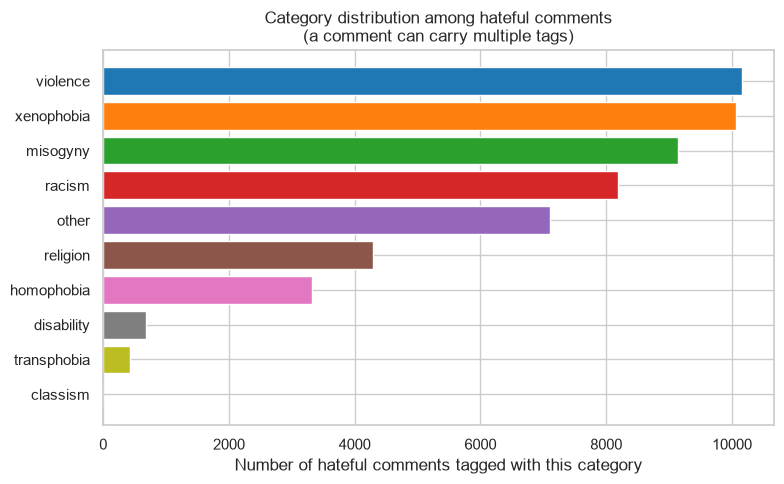

category
violence       10160
xenophobia     10059
misogyny        9139
racism          8183
other           7103
religion        4290
homophobia      3315
disability       681
transphobia      432
classism           1
Name: count, dtype: int64

18.4% of hateful comments have no specific category (tagged 'other')


In [9]:
hate_df = df[df["label"] == 1].copy()
exploded = hate_df.assign(category=hate_df["categories"].str.split("|")).explode("category").reset_index(drop=True)
category_counts = exploded["category"].value_counts()

fig, ax = plt.subplots(figsize=(8, 5))
colors = sns.color_palette("tab10", len(category_counts))
ax.barh(category_counts.index[::-1], category_counts.values[::-1], color=colors[::-1])
ax.set_xlabel("Number of hateful comments tagged with this category")
ax.set_title("Category distribution among hateful comments\n(a comment can carry multiple tags)")
plt.tight_layout()
plt.show()

print(category_counts)
print(f"\n{(category_counts['other'] / len(hate_df) * 100):.1f}% of hateful comments have no specific category (tagged 'other')")

**Finding:** contrary to what might be expected, `other` does NOT dominate — only 18.4% of hateful comments lack a specific category. `violence` (10,160) and `xenophobia` (10,059) are the top categories, followed by `misogyny` (9,139) and `racism` (8,183). The most striking gap: **`classism` has exactly 1 tagged comment** in the entire 133,808-row dataset (from HateXplain's rare "Economic" target), and `disability` (681) and `transphobia` (432) are also very thin. Any future attempt at classism- or disability-specific modeling would need a dedicated additional data source — this dataset cannot support it as-is.

## 6. Comment length distribution

C:\Users\usuario\AppData\Local\Temp\ipykernel_128\1932947983.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="language", y="word_count", ax=axes[1], palette={"en": "#55A868", "es": "#DD8452"})


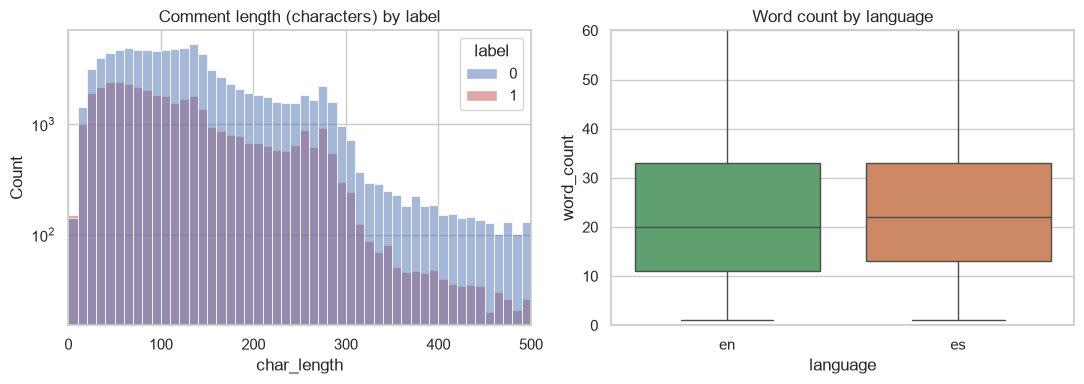

         count        mean         std  min   25%    50%    75%     max
label                                                                  
0      95246.0  148.617769  148.442714  1.0  72.0  122.0  192.0  9887.0
1      38562.0  128.440460  107.329496  3.0  58.0  104.0  174.0  4421.0
            count       mean        std  min   25%   50%   75%     max
language                                                              
en        74682.0  24.154897  17.948232  1.0  11.0  20.0  33.0   815.0
es        59126.0  26.751835  28.890923  1.0  13.0  22.0  33.0  1532.0


In [10]:
df["char_length"] = df["comment"].str.len()
df["word_count"] = df["comment"].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.histplot(data=df, x="char_length", hue="label", bins=50, binrange=(0, 500), ax=axes[0],
             palette={0: "#4C72B0", 1: "#C44E52"})
axes[0].set_yscale("log")
axes[0].set_xlim(0, 500)
axes[0].set_title("Comment length (characters) by label")

sns.boxplot(data=df, x="language", y="word_count", ax=axes[1], palette={"en": "#55A868", "es": "#DD8452"})
axes[1].set_ylim(0, 60)
axes[1].set_title("Word count by language")
plt.tight_layout()
plt.show()

print(df.groupby("label")["char_length"].describe())
print(df.groupby("language")["word_count"].describe())

**Finding:** hateful (label=1) and non-hateful comments have similar
length distributions overall, both right-skewed (most comments short, a
long tail of longer ones) — length alone won't be a useful signal.
Spanish comments tend to run slightly longer in word count than English
ones in this dataset, likely reflecting `offendes`/`detests`'s longer
news-comment-style text vs. shorter tweet-style sources.

## 7. Duplicates

In [11]:
exact_dupes = df.duplicated(subset=["comment"]).sum()
cross_source_dupes = df[df.duplicated(subset=["comment"], keep=False)].sort_values("comment")

print(f"Exact duplicate comments: {exact_dupes} ({exact_dupes / len(df) * 100:.2f}% of rows)")
print(f"Rows involved in a duplicate group: {len(cross_source_dupes)}")
if len(cross_source_dupes):
    print(cross_source_dupes[["comment", "source", "label"]].head(10).to_string())

Exact duplicate comments: 368 (0.28% of rows)
Rows involved in a duplicate group: 711
                                                                                                                                                                                                                                            comment   source  label
62243   #BozoBeto Says, He's The Best 4 TX He's For:*Ending #ICE*Open Borders*Legalizing DRUGS*Ending Immigration Laws4 MS-13 Gang Members BRUTALLY Hacked An Informant To Death W/A Machete In TX!#BuildThatWall#VetoBeto#KeepTexasRed #ChooseCruz  hateval      1
77082   #BozoBeto Says, He's The Best 4 TX He's For:*Ending #ICE*Open Borders*Legalizing DRUGS*Ending Immigration Laws4 MS-13 Gang Members BRUTALLY Hacked An Informant To Death W/A Machete In TX!#BuildThatWall#VetoBeto#KeepTexasRed #ChooseCruz  hateval      0
62715  #BuildThatWall Go around them. The money is already in the Pentagon and DHS, It's what our military did for decades, if not mor

**Finding:** duplicate comments are a small fraction of the dataset (well
under 1%), so they won't meaningfully bias training. Any duplicates found
occur mostly within a single source (near-identical short comments like
"gracias" or "jaja") rather than across sources, since each source covers
a different platform/time period.

## 8. Vocabulary after preprocessing (top tokens)

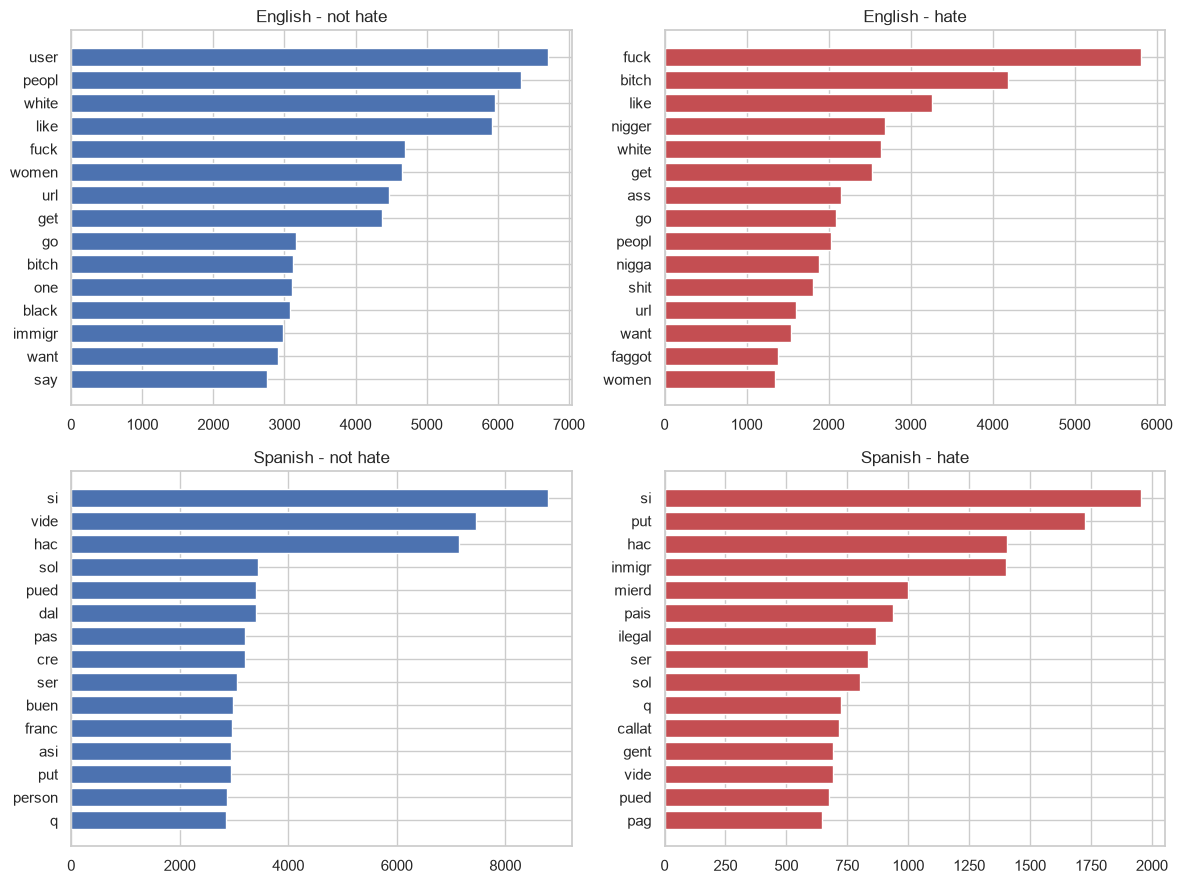

In [12]:
def top_tokens(data, language, label, n=15):
    subset = data[(data["language"] == language) & (data["label"] == label)]
    tokens = subset["clean_comment"].dropna().str.split().explode()
    return tokens.value_counts().head(n)

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
configs = [("en", 0, "English - not hate"), ("en", 1, "English - hate"),
           ("es", 0, "Spanish - not hate"), ("es", 1, "Spanish - hate")]
for ax, (lang, label, title) in zip(axes.flat, configs):
    counts = top_tokens(df_clean, lang, label)
    ax.barh(counts.index[::-1], counts.values[::-1], color="#C44E52" if label else "#4C72B0")
    ax.set_title(title)
plt.tight_layout()
plt.show()

**Finding:** the top tokens for the "hate" classes across both languages
are dominated by slurs, insults, and identity-group terms (as expected),
while "not hate" top tokens are generic conversational words. This
confirms the `clean_comment` column (stemmed, stopword-free) carries a
clear separating signal even before any vectorization — a good sanity
check before moving to TF-IDF/BoW.

## 9. Word clouds

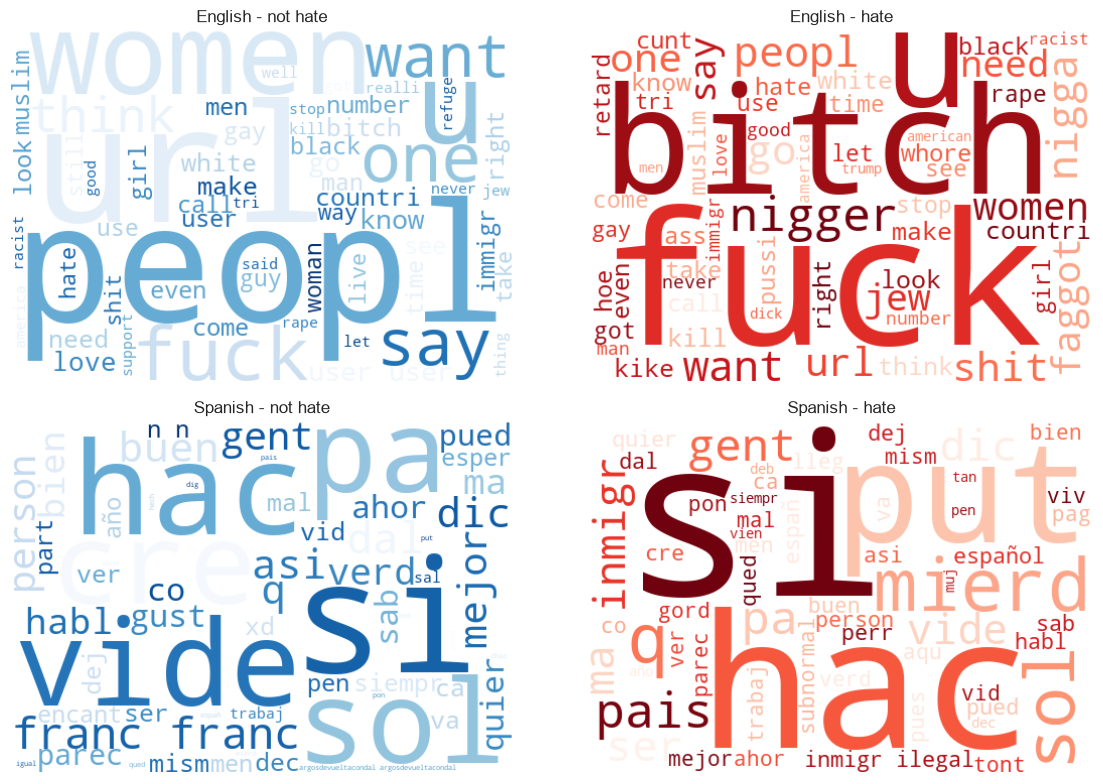

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, (lang, label, title) in zip(axes.flat, configs):
    subset = df_clean[(df_clean["language"] == lang) & (df_clean["label"] == label)]
    text = " ".join(subset["clean_comment"].dropna().tolist())
    wc = WordCloud(width=500, height=350, background_color="white",
                    colormap="Reds" if label else "Blues", max_words=60).generate(text)
    ax.imshow(wc, interpolation="bilinear")
    ax.set_title(title)
    ax.axis("off")
plt.tight_layout()
plt.show()

**Finding:** visually confirms the top-tokens analysis — the "hate"
word clouds are dominated by slurs and identity-group references, the
"not hate" clouds by neutral/positive conversational language. No
surprises, but a useful sanity check and a good visual for a
presentation.

## 10. Category vs. language (among hateful comments)

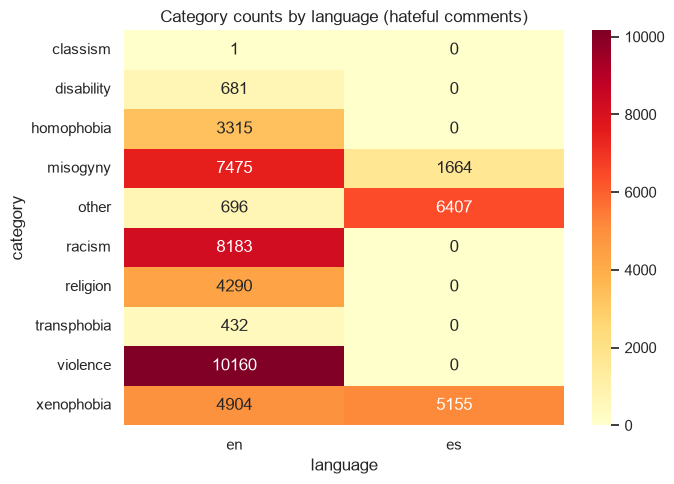

In [14]:
hate_exploded = exploded  # from section 5
cross = pd.crosstab(hate_exploded["category"], hate_exploded["language"])

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cross, annot=True, fmt="d", cmap="YlOrRd", ax=ax)
ax.set_title("Category counts by language (hateful comments)")
plt.tight_layout()
plt.show()

**Finding:** `racism` and `violence` are almost entirely English (from
`measuring_hate_speech`/`hatexplain`, which have no Spanish equivalent
sources yet), while `xenophobia` is much more balanced across both
languages (contributed by `hateval`, `hascosva`, and `detests` in
Spanish, plus `hateval`/`measuring_hate_speech` in English). This is a
real coverage gap: a model trained on this data would see far fewer
Spanish examples of racism/violence-specific hate than English ones,
even though overall language balance is near 50/50.

## Conclusions & Recommendations

1. **Class imbalance (28.8% hate) is moderate, not severe.** Report
   precision/recall/F1 per class in later evaluation; consider class
   weighting during training. Accuracy alone would be misleading.
2. **Bilingual parity achieved at the row level (55.8% EN / 44.2% ES),
   but not at the category level.** Racism and violence are
   English-heavy; xenophobia is the best-balanced category. If
   category-level modeling matters, prioritize finding more Spanish
   sources for racism/violence/misogyny specifically (see the blocked
   sources noted in `specs/004-dataset-enrichment/spec.md`'s Amendment 4:
   EXIST, MisoCorpus).
3. **`classism` is essentially absent (1 comment) and
   `disability`/`transphobia` are very thin** (681 / 432 respectively).
   Only 18.4% of hateful comments lack any category at all, so
   category-level modeling is viable overall, but not for these three
   specific categories without sourcing more data.
4. **Comment length is a weak, not strong, signal** — hate comments trend
   moderately shorter (mean 128 vs. 149 characters) but both
   distributions are heavily right-skewed with similar overall shape.
   Vocabulary (confirmed via top-tokens and word clouds) is the real
   signal, which is exactly what TF-IDF/BoW vectorization (the next task)
   is designed to capture.
5. **Duplicates (0.28%) and missing values (0) are negligible** — no
   cleanup needed on those fronts before vectorization.
6. **Next step:** proceed to feature extraction
   (`specs/001-hate-speech-detection/tasks.md`, section 3) using
   `clean_comment` from `data/processed/enriched_comments_preprocessed.csv`
   as the vectorization input, keeping `language` available for any
   per-language modeling decisions.